In [17]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [18]:
from parrot import py_predictor

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

# Merging data

In [19]:
chopTFs = pd.read_csv("../../../output/ChopTFs_pipeline/speed/exponential_fit.csv", index_col = 0)
chopTFs

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,A+C,A*k,1/k
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,1.156830,0.101060,0.269285,0.069876,-0.408963,0.100999,2.574025,0.667927,0.747866,4.208417,0.924506,ok,0.747866,0.311517,3.713533
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.629568,0.079913,0.132274,0.015466,0.342460,0.078549,5.240241,0.612717,1.971445,3.847695,0.988783,ok,1.972028,0.215549,7.560070
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,1.533139,0.098494,0.128593,0.012426,-0.266570,0.100362,5.390225,0.520850,1.265886,6.853707,0.983280,ok,1.266569,0.197152,7.776451
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,1.098801,0.101313,0.096377,0.021066,0.055955,0.096084,7.192037,1.572054,1.151371,6.613226,0.955792,ok,1.154756,0.105899,10.375916
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,1.508101,0.108744,0.117486,0.022559,0.037501,0.095994,5.899836,1.132839,1.544293,5.651303,0.954109,ok,1.545602,0.177181,8.511664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.563304,0.073382,0.093508,0.008916,-0.208122,0.073789,7.412734,0.706836,1.349461,8.897796,0.966920,ok,1.355182,0.146181,10.694315
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.120782,0.082873,0.080102,0.017744,0.010666,0.080531,8.653300,1.916833,1.122281,8.416834,0.969677,ok,1.131448,0.089777,12.484073
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.598856,0.100220,0.111316,0.014868,-0.181693,0.102116,6.226831,0.831686,1.415154,7.334669,0.977314,ok,1.417164,0.177979,8.983418
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.245690,0.098534,0.084823,0.012658,0.000967,0.104688,8.171657,1.219457,1.238982,8.056112,0.970036,ok,1.246658,0.105664,11.789209


In [20]:
gcn4 = pd.read_csv("../../../output/GCN4_pipeline/speed/exponential_fit.csv", index_col = 0)
gcn4

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k
0,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH,3.619457,0.481638,0.115100,0.036830,0.530625,0.319867,6.022144,1.926989,4.035523,4.569138,0.972274,ok,NaN,4.150082,0.416598,8.688118
1,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.385225,0.553639,0.074620,0.062932,0.601177,0.059638,9.289001,7.834024,1.838727,3.486974,0.960851,ok,NaN,1.986402,0.103366,13.401196
2,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.195991,0.085748,0.146610,0.016995,-0.066138,0.040876,4.727820,0.548043,2.102846,4.869739,0.985961,ok,NaN,2.129853,0.321955,6.820803
3,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.992776,0.123694,0.159460,0.019381,-0.286056,0.118027,4.346844,0.528314,1.690053,5.230461,0.995732,ok,NaN,1.706721,0.317768,6.271170
4,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,2.520940,0.186441,0.155566,0.024089,1.109990,0.154746,4.455660,0.689937,3.607231,2.044088,0.998874,ok,NaN,3.630930,0.392171,6.428159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4708,YTNLTTPGTSYIDSPLYIADSTDTSPLFATDGLGADADSW,3.368061,0.071460,0.141788,0.007293,0.069468,0.051669,4.888605,0.251443,3.389661,4.629259,0.999213,ok,NaN,3.437529,0.477552,7.052766
4709,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,3.441662,0.104211,0.157731,0.008328,0.451281,0.102140,4.394499,0.232036,3.862623,3.547094,0.990357,ok,NaN,3.892943,0.542856,6.339923
4710,YTTASSSSFSSASANILPRDFSVFTTDSQSSWLPSSSPSL,2.523455,0.092592,0.133525,0.011832,0.311140,0.065568,5.191132,0.460007,2.788641,4.208417,0.997692,ok,NaN,2.834594,0.336945,7.489220
4711,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH,1.689938,0.100656,0.055910,0.007066,0.016752,0.031002,12.397552,1.566757,1.390878,9.198397,0.998031,ok,NaN,1.706690,0.094484,17.885887


In [21]:
overlap_tiles = pd.merge(chopTFs[["ADseq", "A+C", "k"]], gcn4[["ADseq", "A+C", "k"]], on = "ADseq", suffixes = ("_chopTFs", "_gcn4"))
overlap_tiles.head()

,ADseq,A+C_chopTFs,k_chopTFs,A+C_gcn4,k_gcn4
0,AKVDTEEEDKTMVDSTSLSWEDLFDFESYSTDLIASINPD,2.349015,0.141336,5.809814,0.218016
1,DAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIPV,1.972101,0.166802,5.235519,0.231907
2,DDAVVESAASSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,1.424435,0.106999,3.806280,0.205857
3,DDAVVESFFSSSTDSTPAAEAENAEDNSKEWTSLFDNDIP,1.199626,0.101248,3.212727,0.149876
4,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,2.099741,0.166732,5.191940,0.239243


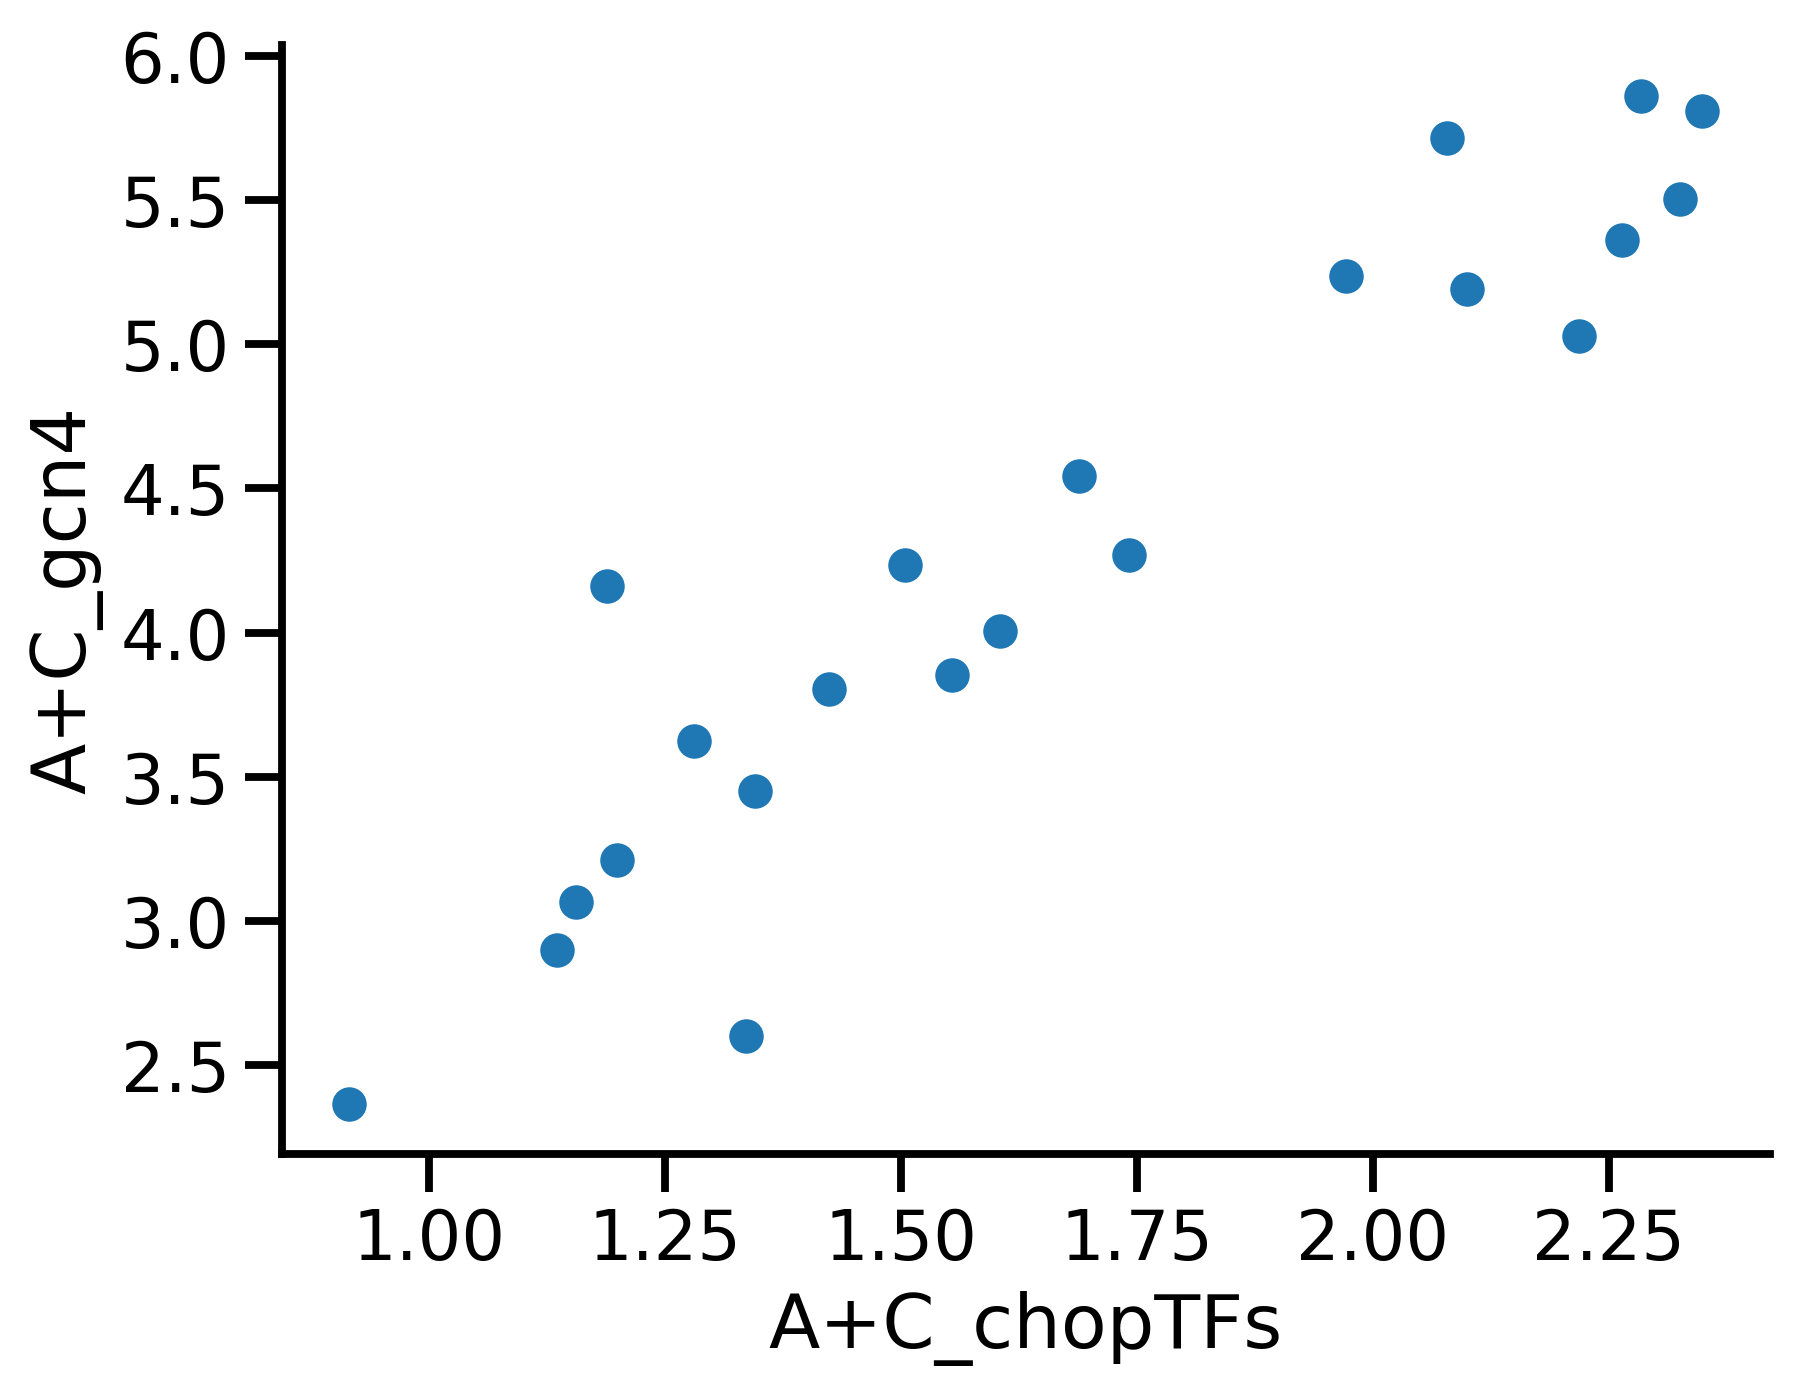

In [22]:
sns.set_context('talk')
plt.figure(dpi = 300)
sns.scatterplot(data = overlap_tiles, x = "A+C_chopTFs", y = "A+C_gcn4")
sns.despine()
plt.show()

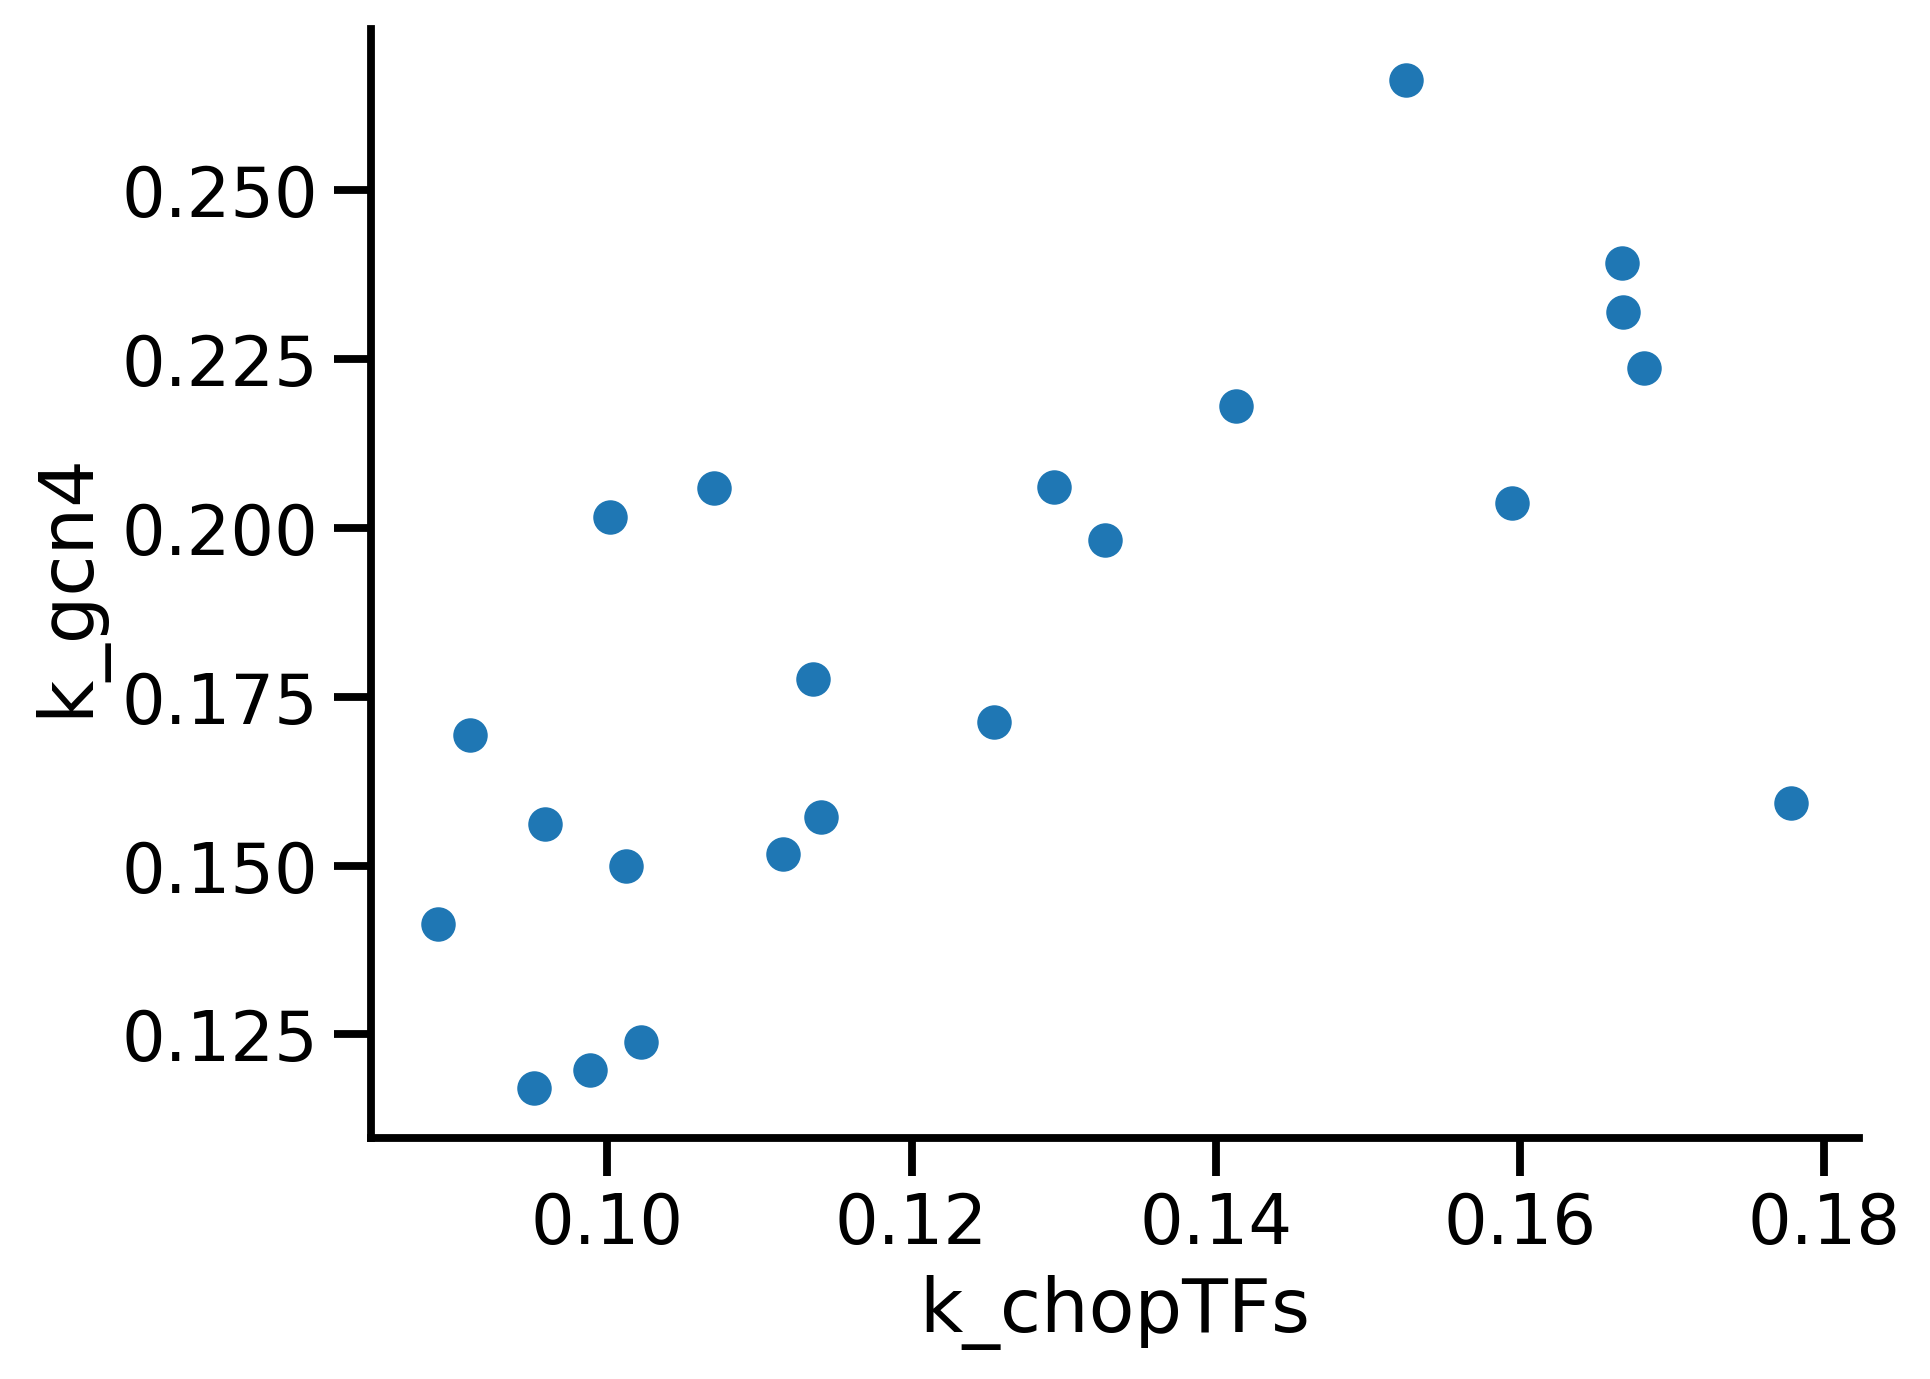

In [23]:
sns.set_context('talk')
plt.figure(dpi = 300)
sns.scatterplot(data = overlap_tiles, x = "k_chopTFs", y = "k_gcn4")
sns.despine()
plt.show()

In [24]:
from scipy import stats

# Find overlapping ADseqs
overlap = set(chopTFs['ADseq']) & set(gcn4['ADseq'])
print(f"Overlapping sequences: {len(overlap)}")

chop_overlap = chopTFs[chopTFs['ADseq'].isin(overlap)].set_index('ADseq')
gcn4_overlap = gcn4[gcn4['ADseq'].isin(overlap)].set_index('ADseq')

# Align on shared index
shared = chop_overlap.index.intersection(gcn4_overlap.index)
chop_aligned = chop_overlap.loc[shared]
gcn4_aligned = gcn4_overlap.loc[shared]

# Fit linear scaling for A+C
slope_ac, intercept_ac, r_ac, _, _ = stats.linregress(chop_aligned['A+C'], gcn4_aligned['A+C'])
print(f"A+C: slope={slope_ac:.3f}, intercept={intercept_ac:.3f}, R={r_ac:.3f}")

# Fit linear scaling for k
slope_k, intercept_k, r_k, _, _ = stats.linregress(chop_aligned['k'], gcn4_aligned['k'])
print(f"k: slope={slope_k:.3f}, intercept={intercept_k:.3f}, R={r_k:.3f}")

# Apply scaling to all chopTFs rows
chopTFs_scaled = chopTFs.copy()
chopTFs_scaled['A+C'] = chopTFs['A+C'] * slope_ac + intercept_ac
chopTFs_scaled['k']   = chopTFs['k']   * slope_k  + intercept_k

# Merge
gcn4_tagged      = gcn4.copy();       gcn4_tagged['source']      = 'gcn4'
chopTFs_tagged   = chopTFs_scaled.copy(); chopTFs_tagged['source'] = 'chopTFs'

merged = pd.concat([gcn4_tagged, chopTFs_tagged], ignore_index=True)
merged

Overlapping sequences: 22
A+C: slope=2.214, intercept=0.574, R=0.939
k: slope=0.960, intercept=0.062, R=0.681


,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k,source
0,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH,3.619457,0.481638,0.115100,0.036830,0.530625,0.319867,6.022144,1.926989,4.035523,4.569138,0.972274,ok,NaN,4.150082,0.416598,8.688118,gcn4
1,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.385225,0.553639,0.074620,0.062932,0.601177,0.059638,9.289001,7.834024,1.838727,3.486974,0.960851,ok,NaN,1.986402,0.103366,13.401196,gcn4
2,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.195991,0.085748,0.146610,0.016995,-0.066138,0.040876,4.727820,0.548043,2.102846,4.869739,0.985961,ok,NaN,2.129853,0.321955,6.820803,gcn4
3,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.992776,0.123694,0.159460,0.019381,-0.286056,0.118027,4.346844,0.528314,1.690053,5.230461,0.995732,ok,NaN,1.706721,0.317768,6.271170,gcn4
4,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,2.520940,0.186441,0.155566,0.024089,1.109990,0.154746,4.455660,0.689937,3.607231,2.044088,0.998874,ok,NaN,3.630930,0.392171,6.428159,gcn4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4954,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.563304,0.073382,0.151535,0.008916,-0.208122,0.073789,7.412734,0.706836,1.349461,8.897796,0.966920,ok,NaN,3.574029,0.146181,10.694315,chopTFs
4955,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.120782,0.082873,0.138668,0.017744,0.010666,0.080531,8.653300,1.916833,1.122281,8.416834,0.969677,ok,NaN,3.078687,0.089777,12.484073,chopTFs
4956,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.598856,0.100220,0.168627,0.014868,-0.181693,0.102116,6.226831,0.831686,1.415154,7.334669,0.977314,ok,NaN,3.711255,0.177979,8.983418,chopTFs
4957,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.245690,0.098534,0.143200,0.012658,0.000967,0.104688,8.171657,1.219457,1.238982,8.056112,0.970036,ok,NaN,3.333759,0.105664,11.789209,chopTFs


In [25]:
merged

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k,source
0,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH,3.619457,0.481638,0.115100,0.036830,0.530625,0.319867,6.022144,1.926989,4.035523,4.569138,0.972274,ok,NaN,4.150082,0.416598,8.688118,gcn4
1,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.385225,0.553639,0.074620,0.062932,0.601177,0.059638,9.289001,7.834024,1.838727,3.486974,0.960851,ok,NaN,1.986402,0.103366,13.401196,gcn4
2,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.195991,0.085748,0.146610,0.016995,-0.066138,0.040876,4.727820,0.548043,2.102846,4.869739,0.985961,ok,NaN,2.129853,0.321955,6.820803,gcn4
3,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.992776,0.123694,0.159460,0.019381,-0.286056,0.118027,4.346844,0.528314,1.690053,5.230461,0.995732,ok,NaN,1.706721,0.317768,6.271170,gcn4
4,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,2.520940,0.186441,0.155566,0.024089,1.109990,0.154746,4.455660,0.689937,3.607231,2.044088,0.998874,ok,NaN,3.630930,0.392171,6.428159,gcn4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4954,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.563304,0.073382,0.151535,0.008916,-0.208122,0.073789,7.412734,0.706836,1.349461,8.897796,0.966920,ok,NaN,3.574029,0.146181,10.694315,chopTFs
4955,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.120782,0.082873,0.138668,0.017744,0.010666,0.080531,8.653300,1.916833,1.122281,8.416834,0.969677,ok,NaN,3.078687,0.089777,12.484073,chopTFs
4956,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.598856,0.100220,0.168627,0.014868,-0.181693,0.102116,6.226831,0.831686,1.415154,7.334669,0.977314,ok,NaN,3.711255,0.177979,8.983418,chopTFs
4957,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.245690,0.098534,0.143200,0.012658,0.000967,0.104688,8.171657,1.219457,1.238982,8.056112,0.970036,ok,NaN,3.333759,0.105664,11.789209,chopTFs


In [26]:
merged.to_csv("../../../output/chopTFs_gcn4_exponential_merged.csv")

# Saving to run PARROT

In [27]:
merged[["ADseq", "k"]].to_csv("../../../output/GCN4_pipeline/speed/PARROT/chopTFs_gcn4_merged_input_k.txt", sep="\t", header=False)

In [28]:
merged[["ADseq", "A+C"]].to_csv("../../../output/GCN4_pipeline/speed/PARROT/chopTFs_gcn4_merged_input_strength.txt", sep="\t", header=False)

# PErformance

In [29]:
def return_preds(path):
    gcn4_speed_preds = pd.read_csv(path, sep = "\t", header = None)
    gcn4_speed_preds["class"] = gcn4_speed_preds[0].str.split("_").str[1].str.split(" ").str[0]
    gcn4_speed_preds["seq"] = gcn4_speed_preds[0].str.split(" ").str[1].str.split(" ").str[0]
    gcn4_speed_preds["val"] = gcn4_speed_preds[0].str.split(" ").str[2].astype(float)
    gcn4_speed_preds = gcn4_speed_preds.drop(columns = 0)
    gcn4_speed_preds = pd.pivot_table(gcn4_speed_preds, index = "seq", columns = "class", values='val', aggfunc="first").reset_index()
    return gcn4_speed_preds

In [30]:
gcn4_speed_preds = return_preds("../../../output/GCN4_pipeline/speed/PARROT/chopTFs_gcn4_merged_k_predictions.tsv")
gcn4_speed_preds

class,seq,PRED,TRUE
0,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH,0.149325,0.115100
1,AAFNELFSPEFSSPQFTAAHDFNTAVPTISPQELLMNQPA,0.123221,0.168235
2,AAIPSSRARSHTAATIPPLDFSVFTTDSLQQSWLPSSSSS,0.120617,0.088964
3,ADAFGSAPPSTAFTNLTSPDINDSPFNDSFDCSPMFQNEP,0.144898,0.126086
4,ADFSAFLPQSAQTDTIDPTIPPTRPSEHSSSSPFFHPLDF,0.129527,0.141328
...,...,...,...
738,YSGHSKLEERGPHQVKATSEIYVDEKRNQNAYEWYGLDPE,0.130898,0.151502
739,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,0.108653,0.059275
740,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,0.181447,0.185546
741,YSPASRSSSSPSYIDFTSVTTASTQSSWLSSPAPHAYRHQ,0.114847,0.182126


In [31]:
gcn4_strength_preds_more_seqs = return_preds("../../../output/GCN4_pipeline/speed/PARROT/chopTFs_gcn4_merged_strength_predictions.tsv")
gcn4_strength_preds_more_seqs

class,seq,PRED,TRUE
0,ADFEEWFSADYSGLQSDYSPLTGVHDTSSPSIGPTISPRE,3.640614,4.037836
1,ADMDLFDEFTAFEGGASTTQNAFPSAYSSPAVPTIYDPSA,3.300376,3.662189
2,ADQVTEDLASFAELLQSTGILESPVPGPLNFCIAPRRSSS,2.531612,2.452934
3,ADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSIG,2.639019,2.515477
4,AEFEGAGDPWFPLFPQDTSAVPEQPSVDNSPAQQSDELES,2.177486,2.519932
...,...,...,...
736,YSDGPSSSGFVSNLGCDDLSDFCNLFDAPPSLTVSPDSVF,4.296557,5.063501
737,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,3.379901,3.711255
738,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,2.747172,3.333759
739,YSPASRSSSSPSTIDFTSVTTASHQSPWLSSPTPNAYRQQ,0.937219,1.036867


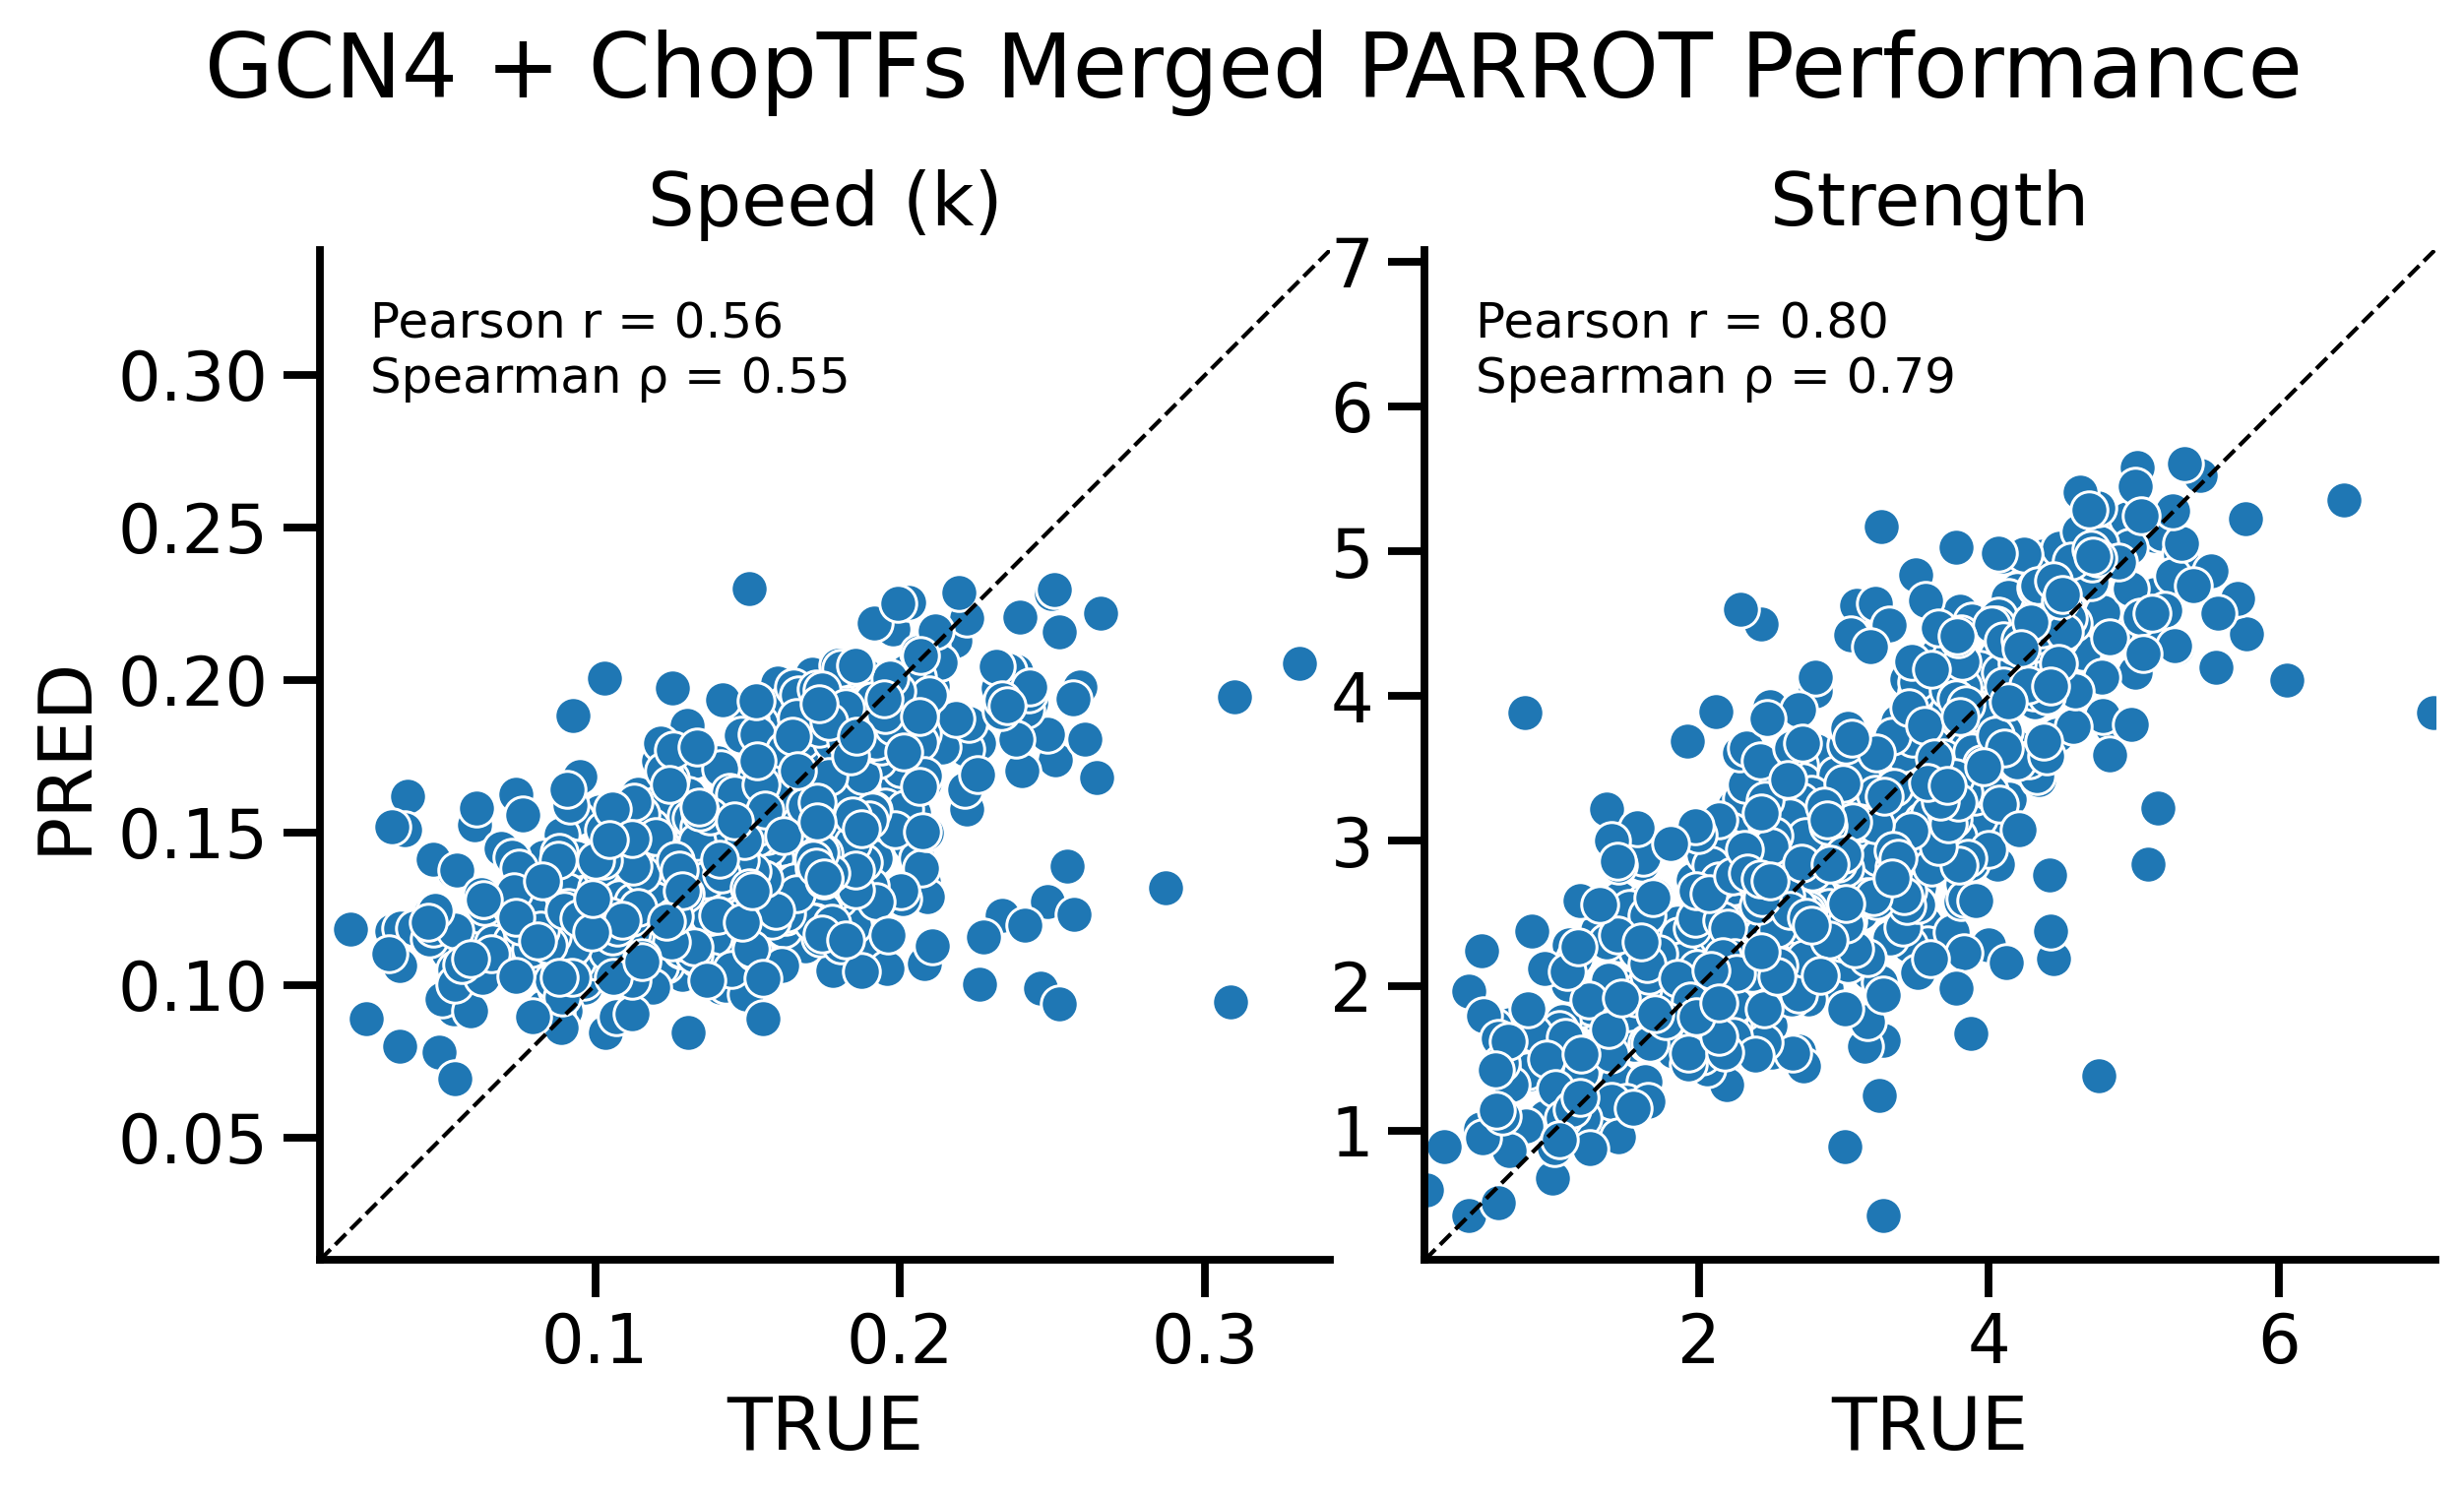

In [32]:
fig,axs = plt.subplots(1,2, dpi = 300, figsize = (8,5))

sns.set_context('talk')



ax = axs[0]
x = gcn4_speed_preds["TRUE"]
y = gcn4_speed_preds["PRED"]

sns.scatterplot(data=gcn4_speed_preds, x="TRUE", y="PRED", ax = ax)

# limits
min_val = min(x.min(), y.min()) - 0.01
max_val = max(x.max(), y.max()) + 0.01

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# y = x line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", linewidth=1)

# correlations
pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

# text annotation
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
)

ax.set_aspect('equal', adjustable='box')
ax.set_title("Speed (k)")

ax = axs[1]
x = gcn4_strength_preds_more_seqs["TRUE"]
y = gcn4_strength_preds_more_seqs["PRED"]

sns.scatterplot(data=gcn4_strength_preds_more_seqs, x="TRUE", y="PRED", ax = ax)

# limits
min_val = min(x.min(), y.min()) - 0.01
max_val = max(x.max(), y.max()) + 0.01

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# y = x line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", linewidth=1)

# correlations
pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

# text annotation
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
)

ax.set_aspect('equal', adjustable='box')
ax.set_ylabel("")
ax.set_title("Strength")

fig.suptitle("GCN4 + ChopTFs Merged PARROT Performance")
fig.tight_layout(pad = 0)
sns.despine()
plt.show()